## Multi-Label Classification

In [1]:
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader 
import seaborn as sns
import numpy as np
from collections import Counter

In [ ]:
# Data Creation & Prep

# Create a synthetic multilabel dataset using Scikit
X, y = make_multilabel_classification(n_samples=10000, n_features=10, n_classes=3, n_labels=2)
X_torch = torch.FloatTensor(X)
y_torch = torch.FloatTensor(y)

X_train, X_test, y_train, y_test = train_test_split(X_torch, y_torch, test_size=0.2)

In [3]:
# Dataloader

class MultilabelDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = X
        self.y = y

    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
    def __len__(self):
        return len(self.X)
    

multilabel_data = MultilabelDataset(X_train, y_train)
train_loader = DataLoader(dataset=multilabel_data, batch_size=10)

In [5]:
class MultilabelNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [6]:
print(f"X_torch.shape: {X_torch.shape} y_torch.shape: {y_torch.shape}")
input_dim = X_torch.shape[1]
output_dim = y_torch.shape[1]

X_torch.shape: torch.Size([10000, 10]) y_torch.shape: torch.Size([10000, 3])


In [8]:
model = MultilabelNetwork(input_size=input_dim, hidden_size=20, output_size=output_dim)
model.train()   # set to training mode, call model.eval for inference/eval mode

MultilabelNetwork(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=3, bias=True)
  (sigmoid): Sigmoid()
)

In [10]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []
slope, bias = [], []
number_epochs = 100
for epoch in range(number_epochs):
    for j, data in enumerate(train_loader):
        
        # optimization
        optimizer.zero_grad()

        # forward pass
        y_hat = model(data[0])

        # compute loss
        loss = loss_fn(y_hat, data[1])
        losses.append(loss.item())

        # backprop
        loss.backward()

        # update weights
        optimizer.step()
    
    if (epoch % 10 == 0):
        print(f"Epoch {epoch}, Loss: {loss.data}")

Epoch 0, Loss: 0.5365378260612488
Epoch 10, Loss: 0.5365378856658936
Epoch 20, Loss: 0.5238749980926514
Epoch 30, Loss: 0.5238749980926514
Epoch 40, Loss: 0.5365378260612488
Epoch 50, Loss: 0.5365378260612488
Epoch 60, Loss: 0.5365378260612488
Epoch 70, Loss: 0.5365378260612488
Epoch 80, Loss: 0.5365378260612488
Epoch 90, Loss: 0.5365378260612488


Naive classifier: 30.0%
Test accuracy: 71.39999999999999%


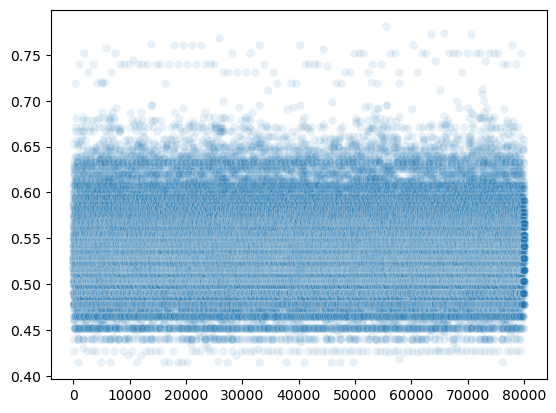

In [15]:
# Plot the losses
sns.scatterplot(x=range(len(losses)), y=losses, alpha=0.1)

# Test the model
X_test_torch = torch.FloatTensor(X_test)
with torch.no_grad():
    y_test_hat = model(X_test_torch).round()
    

# Naive classifier accuracy
# convert [1, 1, 0] to string '[1. 1. 0.]' - use detach to break gradient tracking
y_test_str = [str(i) for i in y_test.detach().numpy()]

most_common_cnt = Counter(y_test_str).most_common()[0][1]
print(f"Naive classifier: {most_common_cnt/len(y_test_str) * 100}%")

# Test accuracy
test_acc = accuracy_score(y_test, y_test_hat)
print(f"Test accuracy: {test_acc * 100}%")